# 📊 E-Commerce Sales Analytics
## Exploratory Data Analysis (EDA)

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [2]:
file_path = r"C:/Users/shaiju/Downloads/Cleaned Data.xlsx"

fact = pd.read_excel(file_path, sheet_name="Fact Table Final")
customers = pd.read_excel(file_path, sheet_name="Dim Customers")
products = pd.read_excel(file_path, sheet_name="Dim Product")
promotions = pd.read_excel(file_path, sheet_name="Dim Promotion ")


## 3. Dataset Overview

In [3]:
print(fact.shape)
fact.head()
fact.info()
fact.describe(include='all')


(3510, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date (dd/mm/yyyy)    3510 non-null   datetime64[ns]
 1   CustomerID           3510 non-null   int64         
 2   PromotionID          3510 non-null   object        
 3   Product ID           3510 non-null   object        
 4   Units Sold           3510 non-null   int64         
 5   Price Per Unit       3510 non-null   int64         
 6   Total Sales          3510 non-null   int64         
 7   Discount Percentage  3510 non-null   int64         
 8   Discount Value       3510 non-null   float64       
 9   Net Sales            3510 non-null   float64       
 10  Profit               3510 non-null   float64       
 11  Order ID             3510 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(6), object(2)
memory usage: 329.2+ KB


,Date (dd/mm/yyyy),CustomerID,PromotionID,Product ID,Units Sold,Price Per Unit,Total Sales,Discount Percentage,Discount Value,Net Sales,Profit,Order ID
count,3510,3510.000000,3510,3510,3510.000000,3510.000000,3510.00000,3510.000000,3510.000000,3510.000000,3510.000000,3510.00000
unique,NaN,NaN,6,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,0,P017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2790,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2022-01-14 20:40:12.307692032,25.723362,NaN,NaN,2.029915,17624.227920,36892.89886,5.663818,2047.339715,34845.559145,3484.555915,1755.50000
min,2020-01-01 00:00:00,1.000000,NaN,NaN,1.000000,99.000000,99.00000,0.000000,0.000000,29.700000,2.970000,1.00000
25%,2021-01-01 00:00:00,13.000000,NaN,NaN,1.000000,1999.000000,3499.00000,0.000000,0.000000,2999.000000,299.900000,878.25000
50%,2022-01-22 00:00:00,26.000000,NaN,NaN,2.000000,5499.000000,8999.00000,0.000000,0.000000,8798.400000,879.840000,1755.50000
75%,2023-01-30 18:00:00,38.000000,NaN,NaN,3.000000,12999.000000,25998.00000,0.000000,0.000000,25497.000000,2549.700000,2632.75000
max,2024-01-01 00:00:00,50.000000,NaN,NaN,3.000000,92499.000000,277497.00000,70.000000,194247.900000,277497.000000,27749.700000,3510.00000


## 4. Data Quality

In [4]:
for name, df in {'Fact':fact,'Customers':customers,'Products':products,'Promotions':promotions}.items():
    print("="*60)
    print(name)
    print(df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())


Fact
Date (dd/mm/yyyy)      0
CustomerID             0
PromotionID            0
Product ID             0
Units Sold             0
Price Per Unit         0
Total Sales            0
Discount Percentage    0
Discount Value         0
Net Sales              0
Profit                 0
Order ID               0
dtype: int64
Duplicates: 0
Customers
Customer ID      0
Customer Name    0
City             0
State            0
Pincode          0
EmailID          0
Phone Number     0
dtype: int64
Duplicates: 0
Products
ProductID       0
Product Name    0
Product Line    0
Price (INR)     0
dtype: int64
Duplicates: 0
Promotions
PromotionID             0
Promotion Name          0
Ad Type                 0
Coupon Code             0
Price Reduction Type    0
dtype: int64
Duplicates: 0


## 5. Feature Engineering

In [5]:
fact["Date (dd/mm/yyyy)"] = pd.to_datetime(fact["Date (dd/mm/yyyy)"])
fact["Year"] = fact["Date (dd/mm/yyyy)"].dt.year
fact["Quarter"] = fact["Date (dd/mm/yyyy)"].dt.quarter
fact["Month"] = fact["Date (dd/mm/yyyy)"].dt.month_name()
fact["Weekday"] = fact["Date (dd/mm/yyyy)"].dt.day_name()
fact["Profit Margin"] = (fact["Profit"] / fact["Net Sales"]) * 100


## 6. Merge Tables

In [6]:
print(fact.columns.tolist())
print(customers.columns.tolist())
print(products.columns.tolist())
print(promotions.columns.tolist())

# Update the merge keys based on the printed columns.
master = fact.copy()


['Date (dd/mm/yyyy)', 'CustomerID', 'PromotionID', 'Product ID', 'Units Sold', 'Price Per Unit', 'Total Sales', 'Discount Percentage', 'Discount Value', 'Net Sales', 'Profit', 'Order ID', 'Year', 'Quarter', 'Month', 'Weekday', 'Profit Margin']
['Customer ID', 'Customer Name', 'City', 'State', 'Pincode', 'EmailID', 'Phone Number']
['ProductID', 'Product Name', 'Product Line', 'Price (INR)']
['PromotionID', 'Promotion Name', 'Ad Type', 'Coupon Code', 'Price Reduction Type']


## 7. KPI Summary

In [7]:
print("Total Sales:", fact["Total Sales"].sum())
print("Net Sales:", fact["Net Sales"].sum())
print("Profit:", fact["Profit"].sum())
print("Orders:", fact["Order ID"].nunique())


Total Sales: 129494075
Net Sales: 122307912.6
Profit: 12230791.260000002
Orders: 3510


## Monthly Net Sales

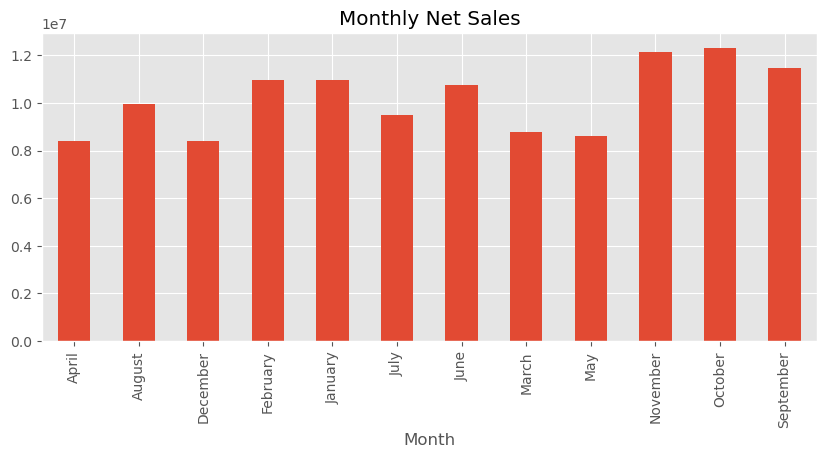

In [8]:
fact.groupby('Month')['Net Sales'].sum().plot(kind='bar', figsize=(10,4)); plt.title('Monthly Net Sales'); plt.show()

## Monthly Profit

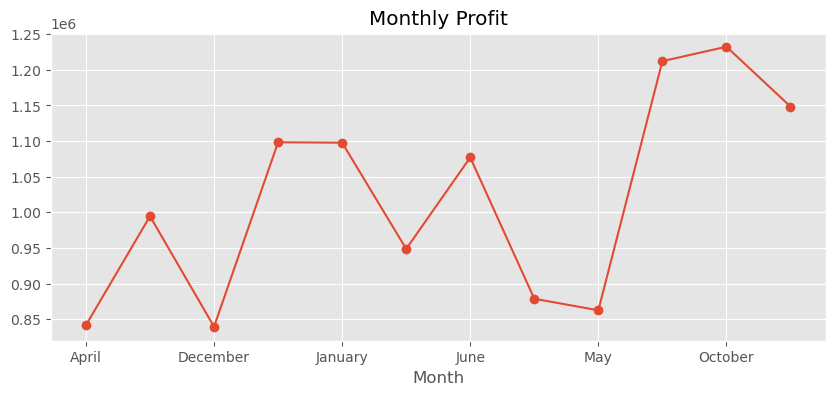

In [9]:
fact.groupby('Month')['Profit'].sum().plot(marker='o', figsize=(10,4)); plt.title('Monthly Profit'); plt.show()

## Sales Distribution

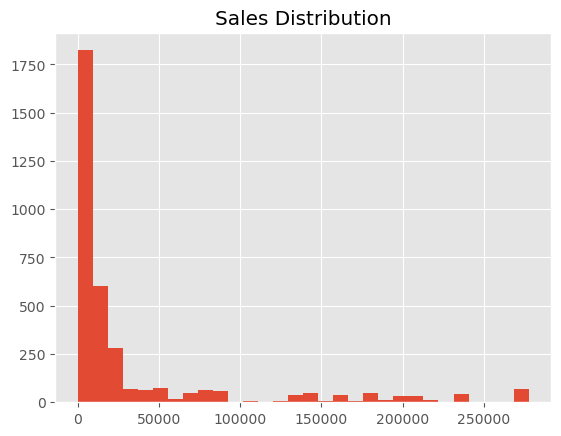

In [10]:
fact['Net Sales'].hist(bins=30); plt.title('Sales Distribution'); plt.show()

## Profit Distribution

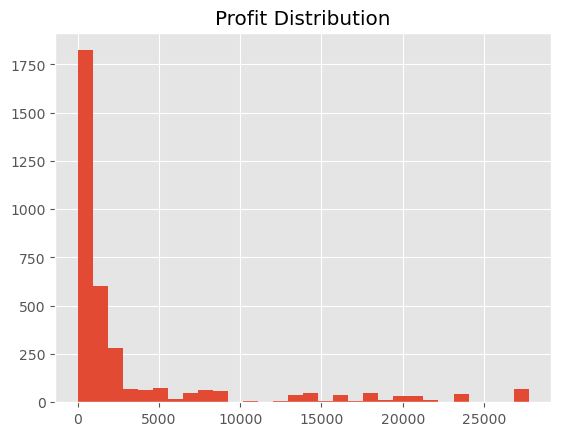

In [11]:
fact['Profit'].hist(bins=30); plt.title('Profit Distribution'); plt.show()

## Discount Distribution

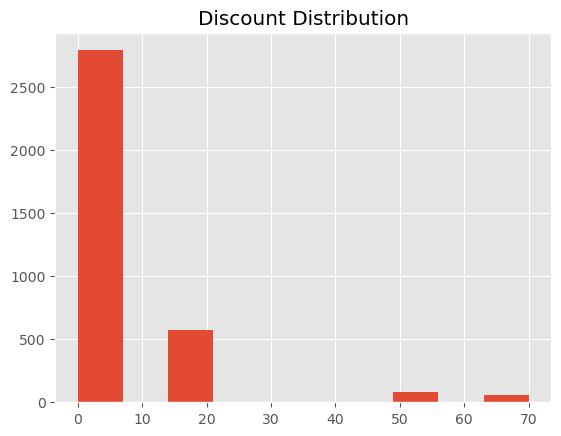

In [12]:
fact['Discount Percentage'].hist(); plt.title('Discount Distribution'); plt.show()

## Top Products

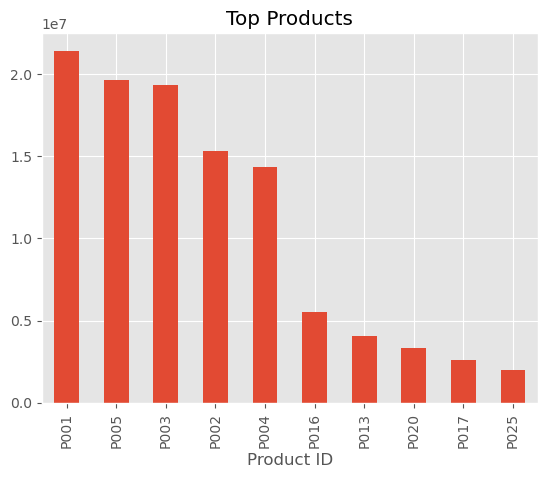

In [13]:
fact.groupby('Product ID')['Net Sales'].sum().nlargest(10).plot(kind='bar'); plt.title('Top Products'); plt.show()

## Top Customers

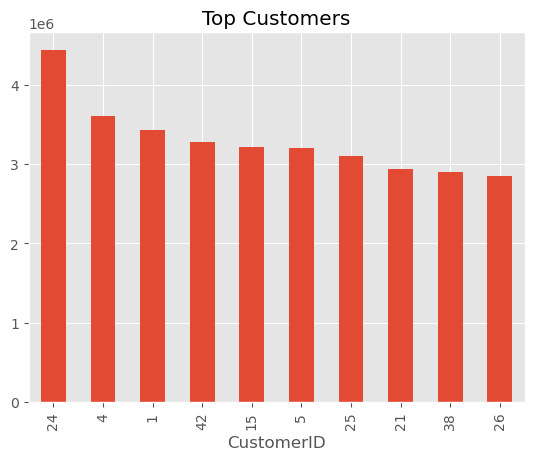

In [14]:
fact.groupby('CustomerID')['Net Sales'].sum().nlargest(10).plot(kind='bar'); plt.title('Top Customers'); plt.show()

## Promotion Performance

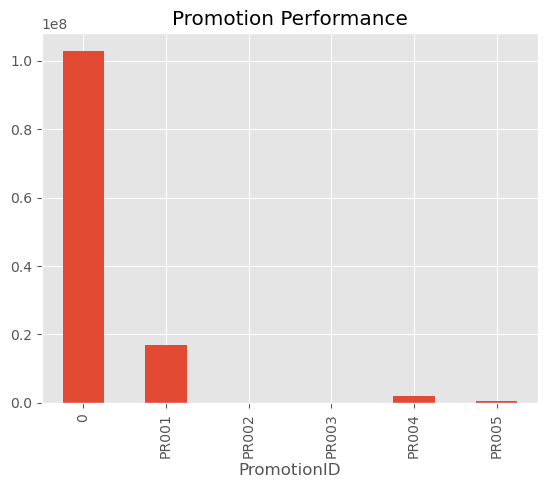

In [15]:
fact.groupby('PromotionID')['Net Sales'].sum().plot(kind='bar'); plt.title('Promotion Performance'); plt.show()

## Profit vs Discount

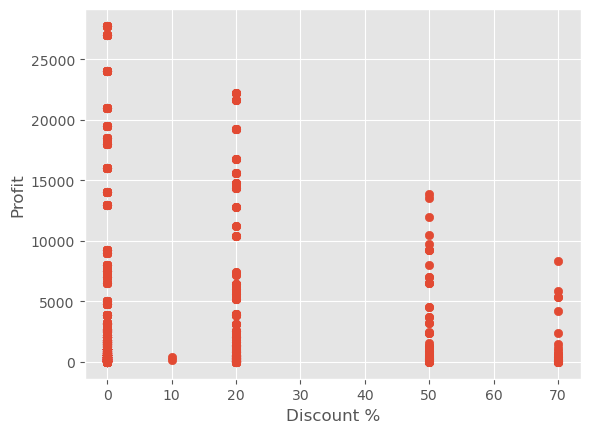

In [16]:
plt.scatter(fact['Discount Percentage'], fact['Profit']); plt.xlabel('Discount %'); plt.ylabel('Profit'); plt.show()

## Profit Outliers

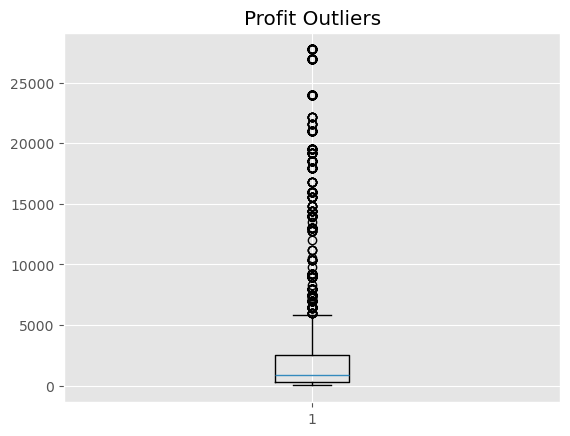

In [17]:
plt.boxplot(fact['Profit']); plt.title('Profit Outliers'); plt.show()

## Business Insights
Add observations below each chart explaining the business impact.

## Recommendations
- Focus on profitable products.
- Optimize discounts.
- Improve promotion effectiveness.
- Expand high-performing regions.

In [18]:
print(fact.columns.tolist())
print(customers.columns.tolist())
print(products.columns.tolist())
print(promotions.columns.tolist())

['Date (dd/mm/yyyy)', 'CustomerID', 'PromotionID', 'Product ID', 'Units Sold', 'Price Per Unit', 'Total Sales', 'Discount Percentage', 'Discount Value', 'Net Sales', 'Profit', 'Order ID', 'Year', 'Quarter', 'Month', 'Weekday', 'Profit Margin']
['Customer ID', 'Customer Name', 'City', 'State', 'Pincode', 'EmailID', 'Phone Number']
['ProductID', 'Product Name', 'Product Line', 'Price (INR)']
['PromotionID', 'Promotion Name', 'Ad Type', 'Coupon Code', 'Price Reduction Type']


In [19]:
# Merge Customer Dimension
master = fact.merge(
    customers,
    left_on="CustomerID",
    right_on="Customer ID",
    how="left"
)

# Merge Product Dimension
master = master.merge(
    products,
    left_on="Product ID",
    right_on="ProductID",
    how="left"
)

# Merge Promotion Dimension
master = master.merge(
    promotions,
    on="PromotionID",
    how="left"
)

print(master.shape)
master.head()

(3510, 32)


,Date (dd/mm/yyyy),CustomerID,PromotionID,Product ID,Units Sold,Price Per Unit,Total Sales,Discount Percentage,Discount Value,Net Sales,Profit,Order ID,Year,Quarter,Month,Weekday,Profit Margin,Customer ID,Customer Name,City,State,Pincode,EmailID,Phone Number,ProductID,Product Name,Product Line,Price (INR),Promotion Name,Ad Type,Coupon Code,Price Reduction Type
0,2020-01-30,1,0,P018,1,2299,2299,0,0.0,2299.0,229.9,29,2020,1,January,Thursday,10.0,1,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,P018,Prestige Pressure Cooker,Home Appliances,2299,NaN,NaN,NaN,NaN
1,2021-12-31,1,0,P008,3,5499,16497,0,0.0,16497.0,1649.7,1806,2021,4,December,Friday,10.0,1,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,P008,Puma Sports Shoes,Footwear,5499,NaN,NaN,NaN,NaN
2,2022-06-15,1,0,P008,3,5499,16497,0,0.0,16497.0,1649.7,2123,2022,2,June,Wednesday,10.0,1,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,P008,Puma Sports Shoes,Footwear,5499,NaN,NaN,NaN,NaN
3,2020-06-02,1,0,P013,3,15999,47997,0,0.0,47997.0,4799.7,496,2020,2,June,Tuesday,10.0,1,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,P013,Raymond Suit,Clothing,15999,NaN,NaN,NaN,NaN
4,2020-06-28,1,0,P009,3,3499,10497,0,0.0,10497.0,1049.7,561,2020,2,June,Sunday,10.0,1,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,P009,Levi's Denim Jeans,Clothing,3499,NaN,NaN,NaN,NaN


In [20]:
master.drop(columns=["Customer ID", "ProductID"], inplace=True)

master.head()

,Date (dd/mm/yyyy),CustomerID,PromotionID,Product ID,Units Sold,Price Per Unit,Total Sales,Discount Percentage,Discount Value,Net Sales,Profit,Order ID,Year,Quarter,Month,Weekday,Profit Margin,Customer Name,City,State,Pincode,EmailID,Phone Number,Product Name,Product Line,Price (INR),Promotion Name,Ad Type,Coupon Code,Price Reduction Type
0,2020-01-30,1,0,P018,1,2299,2299,0,0.0,2299.0,229.9,29,2020,1,January,Thursday,10.0,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,Prestige Pressure Cooker,Home Appliances,2299,NaN,NaN,NaN,NaN
1,2021-12-31,1,0,P008,3,5499,16497,0,0.0,16497.0,1649.7,1806,2021,4,December,Friday,10.0,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,Puma Sports Shoes,Footwear,5499,NaN,NaN,NaN,NaN
2,2022-06-15,1,0,P008,3,5499,16497,0,0.0,16497.0,1649.7,2123,2022,2,June,Wednesday,10.0,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,Puma Sports Shoes,Footwear,5499,NaN,NaN,NaN,NaN
3,2020-06-02,1,0,P013,3,15999,47997,0,0.0,47997.0,4799.7,496,2020,2,June,Tuesday,10.0,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,Raymond Suit,Clothing,15999,NaN,NaN,NaN,NaN
4,2020-06-28,1,0,P009,3,3499,10497,0,0.0,10497.0,1049.7,561,2020,2,June,Sunday,10.0,Aarav Singh,Nagpur,Maharashtra,440001,1Aarav@gmail.com,860135097,Levi's Denim Jeans,Clothing,3499,NaN,NaN,NaN,NaN


In [21]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date (dd/mm/yyyy)     3510 non-null   datetime64[ns]
 1   CustomerID            3510 non-null   int64         
 2   PromotionID           3510 non-null   object        
 3   Product ID            3510 non-null   object        
 4   Units Sold            3510 non-null   int64         
 5   Price Per Unit        3510 non-null   int64         
 6   Total Sales           3510 non-null   int64         
 7   Discount Percentage   3510 non-null   int64         
 8   Discount Value        3510 non-null   float64       
 9   Net Sales             3510 non-null   float64       
 10  Profit                3510 non-null   float64       
 11  Order ID              3510 non-null   int64         
 12  Year                  3510 non-null   int32         
 13  Quarter           

In [22]:
master.describe(include="all")

,Date (dd/mm/yyyy),CustomerID,PromotionID,Product ID,Units Sold,Price Per Unit,Total Sales,Discount Percentage,Discount Value,Net Sales,Profit,Order ID,Year,Quarter,Month,Weekday,Profit Margin,Customer Name,City,State,Pincode,EmailID,Phone Number,Product Name,Product Line,Price (INR),Promotion Name,Ad Type,Coupon Code,Price Reduction Type
count,3510,3510.000000,3510,3510,3510.000000,3510.000000,3510.00000,3510.000000,3510.000000,3510.000000,3510.000000,3510.00000,3510.000000,3510.000000,3510,3510,3.510000e+03,3510,3510,3510,3510.000000,3510,3.510000e+03,3510,3510,3510.000000,720,720,720,720
unique,NaN,NaN,6,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,7,NaN,50,16,12,NaN,50,NaN,30,8,NaN,5,5,5,5
top,NaN,NaN,0,P017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,December,Tuesday,NaN,Rhea Bakshi,Kanpur,Maharashtra,NaN,35Rhea@gmail.com,NaN,IFB Microwave Oven,Clothing,NaN,Summer Sale,Email,SUMMER21,20% off
freq,NaN,NaN,2790,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,318,555,NaN,83,427,764,NaN,83,NaN,134,607,NaN,574,574,574,574
mean,2022-01-14 20:40:12.307692032,25.723362,NaN,NaN,2.029915,17624.227920,36892.89886,5.663818,2047.339715,34845.559145,3484.555915,1755.50000,2021.538177,2.511396,NaN,NaN,1.000000e+01,NaN,NaN,NaN,409580.202279,NaN,8.939270e+08,NaN,NaN,17624.227920,NaN,NaN,NaN,NaN
min,2020-01-01 00:00:00,1.000000,NaN,NaN,1.000000,99.000000,99.00000,0.000000,0.000000,29.700000,2.970000,1.00000,2020.000000,1.000000,NaN,NaN,1.000000e+01,NaN,NaN,NaN,110001.000000,NaN,8.040381e+08,NaN,NaN,99.000000,NaN,NaN,NaN,NaN
25%,2021-01-01 00:00:00,13.000000,NaN,NaN,1.000000,1999.000000,3499.00000,0.000000,0.000000,2999.000000,299.900000,878.25000,2021.000000,1.250000,NaN,NaN,1.000000e+01,NaN,NaN,NaN,302001.000000,NaN,8.398987e+08,NaN,NaN,1999.000000,NaN,NaN,NaN,NaN
50%,2022-01-22 00:00:00,26.000000,NaN,NaN,2.000000,5499.000000,8999.00000,0.000000,0.000000,8798.400000,879.840000,1755.50000,2022.000000,3.000000,NaN,NaN,1.000000e+01,NaN,NaN,NaN,411001.000000,NaN,8.948884e+08,NaN,NaN,5499.000000,NaN,NaN,NaN,NaN
75%,2023-01-30 18:00:00,38.000000,NaN,NaN,3.000000,12999.000000,25998.00000,0.000000,0.000000,25497.000000,2549.700000,2632.75000,2023.000000,4.000000,NaN,NaN,1.000000e+01,NaN,NaN,NaN,462001.000000,NaN,9.430556e+08,NaN,NaN,12999.000000,NaN,NaN,NaN,NaN
max,2024-01-01 00:00:00,50.000000,NaN,NaN,3.000000,92499.000000,277497.00000,70.000000,194247.900000,277497.000000,27749.700000,3510.00000,2024.000000,4.000000,NaN,NaN,1.000000e+01,NaN,NaN,NaN,800001.000000,NaN,9.883685e+08,NaN,NaN,92499.000000,NaN,NaN,NaN,NaN


In [23]:
master.isnull().sum()

Date (dd/mm/yyyy)          0
CustomerID                 0
PromotionID                0
Product ID                 0
Units Sold                 0
Price Per Unit             0
Total Sales                0
Discount Percentage        0
Discount Value             0
Net Sales                  0
Profit                     0
Order ID                   0
Year                       0
Quarter                    0
Month                      0
Weekday                    0
Profit Margin              0
Customer Name              0
City                       0
State                      0
Pincode                    0
EmailID                    0
Phone Number               0
Product Name               0
Product Line               0
Price (INR)                0
Promotion Name          2790
Ad Type                 2790
Coupon Code             2790
Price Reduction Type    2790
dtype: int64

In [24]:
master.duplicated().sum()

np.int64(0)

In [26]:
master.to_csv("master_dataset.csv", index=False)

***Sales Analysis***

In [28]:
master.groupby("Month")["Net Sales"].sum()

Month
April         8414670.4
August        9945088.0
December      8393474.0
February     10982629.0
January      10976878.0
July          9485609.0
June         10769879.0
March         8785965.0
May           8624028.8
November     12121323.0
October      12324091.4
September    11484277.0
Name: Net Sales, dtype: float64

In [29]:
master.groupby("Quarter")["Net Sales"].sum()

Quarter
1    30745472.0
2    27808578.2
3    30914974.0
4    32838888.4
Name: Net Sales, dtype: float64

In [30]:
master.groupby("Year")["Net Sales"].sum()

Year
2020    31366267.0
2021    29951422.5
2022    28641357.0
2023    32298868.1
2024       49998.0
Name: Net Sales, dtype: float64

***Product Analysis***

In [31]:
master.groupby("Product Line")["Net Sales"].sum().sort_values(ascending=False)

Product Line
Electronics        90105865.0
Home Appliances    11486430.8
Clothing            6387333.5
Footwear            4744585.2
Accessories         4535440.0
Bags                3755491.5
Kitchenware          940239.0
Personal Care        352527.6
Name: Net Sales, dtype: float64

In [32]:
master.groupby("Product Name")["Profit"].sum().nlargest(10)

Product Name
Apple iPhone 14                2143973.20
Apple MacBook Air              1964678.76
Sony Bravia 55" TV             1935878.49
Samsung Galaxy S21             1530878.13
HP Pavilion Laptop             1435177.92
LG Washing Machine              551977.92
Raymond Suit                    408614.46
Fossil Smartwatch               329784.63
IFB Microwave Oven              256700.55
American Tourister Suitcase     195728.25
Name: Profit, dtype: float64

***Customer Analysis***

In [36]:
master.groupby("Customer Name")["Net Sales"].sum().nlargest(10)

Customer Name
Mohit Aggarwal    4436668.6
Ananya Mehta      3610296.8
Aarav Singh       3426344.6
Shikha Pandey     3278225.2
Jaya Kumar        3212171.6
Aniket Sharma     3200222.4
Naina Chauhan     3105303.2
Lavanya Jain      2930803.2
Saanvi Pillai     2904886.3
Neha Sinha        2852316.5
Name: Net Sales, dtype: float64

In [37]:
master.groupby("State")["Net Sales"].sum()

State
Andhra Pradesh     4558340.6
Bihar              7250423.3
Delhi              5535788.3
Gujarat            4953257.4
Karnataka          1549046.0
Madhya Pradesh    28812928.9
Maharashtra       25458509.3
Rajasthan          6138460.1
Tamil Nadu         5516747.1
Telangana          3288540.6
Uttar Pradesh     24593097.7
West Bengal        4652773.3
Name: Net Sales, dtype: float64

In [38]:
master.groupby("City")["Net Sales"].sum()

City
Ahmedabad         4953257.4
Bangalore         1549046.0
Bhopal           15403536.3
Chennai           5516747.1
Delhi             5535788.3
Hyderabad         3288540.6
Indore           13409392.6
Jaipur            6138460.1
Kanpur           14054508.5
Kolkata           4652773.3
Lucknow          10538589.2
Mumbai            9989876.4
Nagpur            6028989.7
Patna             7250423.3
Pune              9439643.2
Visakhapatnam     4558340.6
Name: Net Sales, dtype: float64

***Promotion Analysis***

In [39]:
master.groupby("Promotion Name")["Net Sales"].sum()

Promotion Name
Clearance Sale          448242.0
Festive Diwali            5396.4
New Year Special          6447.0
Summer Sale           17038699.2
Weekend Flash Sale     1873543.0
Name: Net Sales, dtype: float64

In [40]:
master.groupby("Ad Type")["Profit"].sum()

Ad Type
Email             1703869.92
In-App              44824.20
Mobile Push        187354.30
Social Media          539.64
Website Banner        644.70
Name: Profit, dtype: float64

In [41]:
master.groupby("Price Reduction Type")["Profit"].sum()

Price Reduction Type
10% off                 539.64
20% off             1703869.92
50% off              187354.30
70% off               44824.20
Buy 1 Get 1 Free        644.70
Name: Profit, dtype: float64

***Financial Analysis***

In [42]:
master.groupby("Month")["Profit"].sum()

Month
April         841467.04
August        994508.80
December      839347.40
February     1098262.90
January      1097687.80
July          948560.90
June         1076987.90
March         878596.50
May           862402.88
November     1212132.30
October      1232409.14
September    1148427.70
Name: Profit, dtype: float64

In [44]:
master["Profit Margin"] = (
    master["Profit"] /
    master["Net Sales"]
) * 100

In [45]:
master["Profit Margin"].describe()

count    3.510000e+03
mean     1.000000e+01
std      1.122025e-16
min      1.000000e+01
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.000000e+01
Name: Profit Margin, dtype: float64

***Discount Analysis***

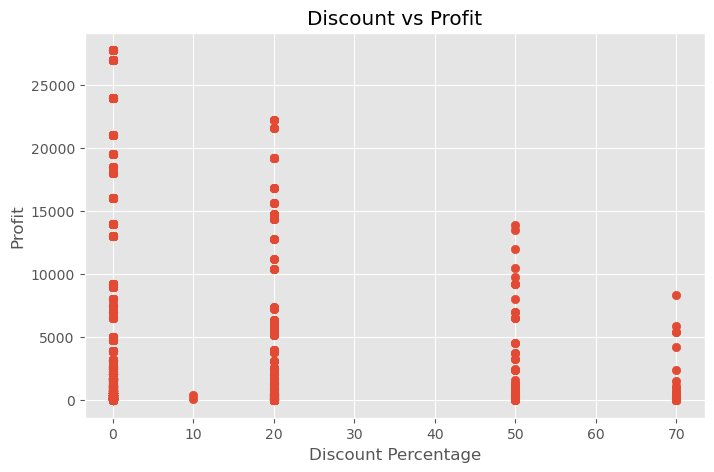

In [47]:
plt.figure(figsize=(8,5))

plt.scatter(
    master["Discount Percentage"],
    master["Profit"]
)

plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.title("Discount vs Profit")

plt.show()

***Profit Distribution***

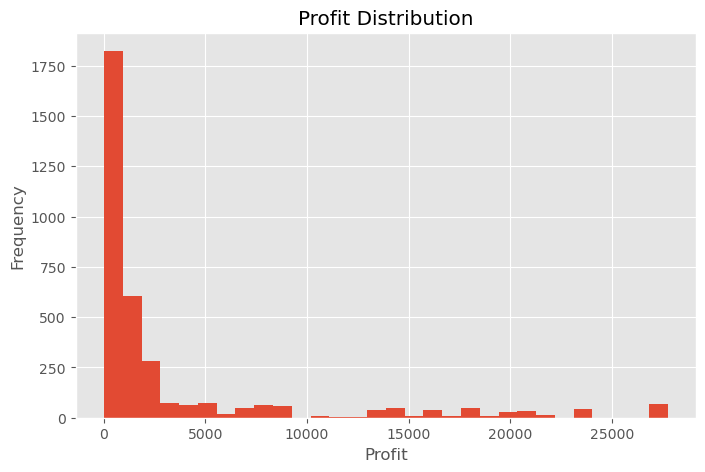

In [48]:
plt.figure(figsize=(8,5))

plt.hist(master["Profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

***Sales Distribution***

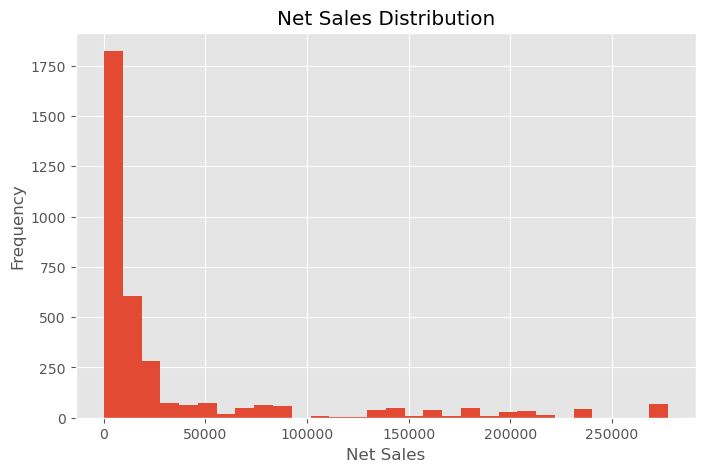

In [50]:
plt.figure(figsize=(8,5))

plt.hist(master["Net Sales"], bins=30)

plt.title("Net Sales Distribution")
plt.xlabel("Net Sales")
plt.ylabel("Frequency")

plt.show()

***Profit Margin Analysis***

In [51]:
master["Profit Margin"].describe()

count    3.510000e+03
mean     1.000000e+01
std      1.122025e-16
min      1.000000e+01
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      1.000000e+01
Name: Profit Margin, dtype: float64

In [62]:
import numpy as np

master["Profit Margin"] = np.where(
    master["Net Sales"] != 0,
    (master["Profit"] / master["Net Sales"]) * 100,
    np.nan
)
master["Profit Margin"] = master["Profit Margin"].replace([np.inf, -np.inf], np.nan)
profit_margin = master["Profit Margin"]

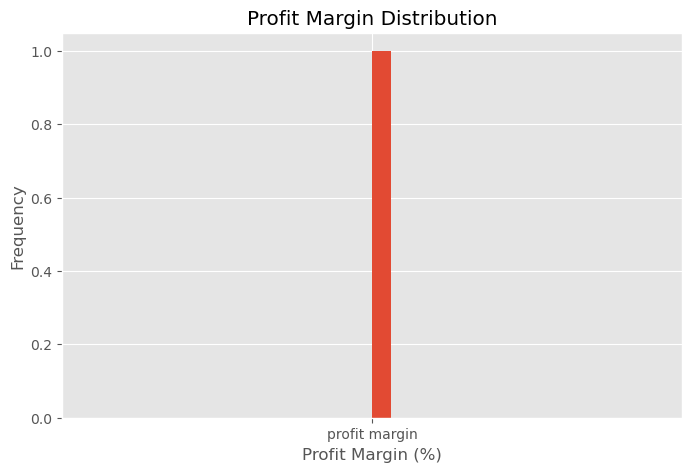

In [69]:
profit_margin = master["Profit Margin"].dropna()

plt.figure(figsize=(8,5))
plt.hist("profit margin", bins=30)

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")

plt.show()

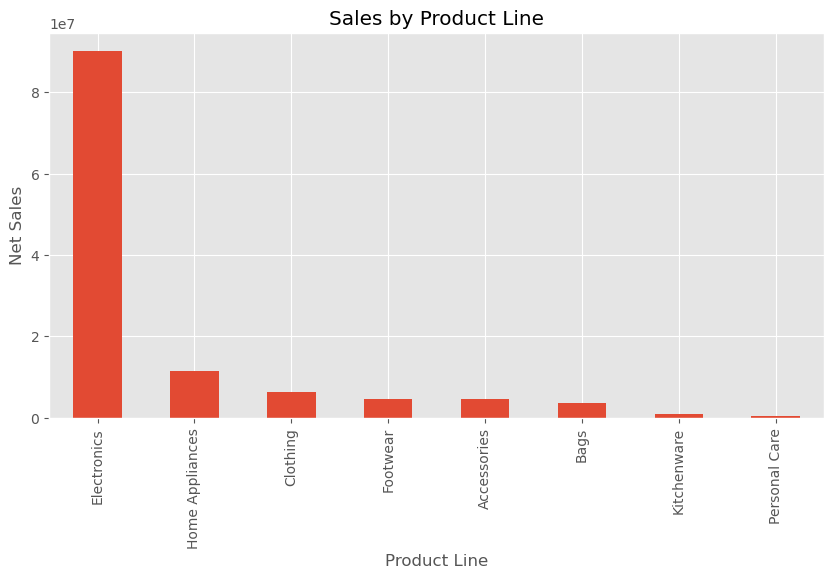

In [70]:
sales_product = (
    master.groupby("Product Line")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sales_product.plot(kind="bar")

plt.title("Sales by Product Line")
plt.ylabel("Net Sales")

plt.show()

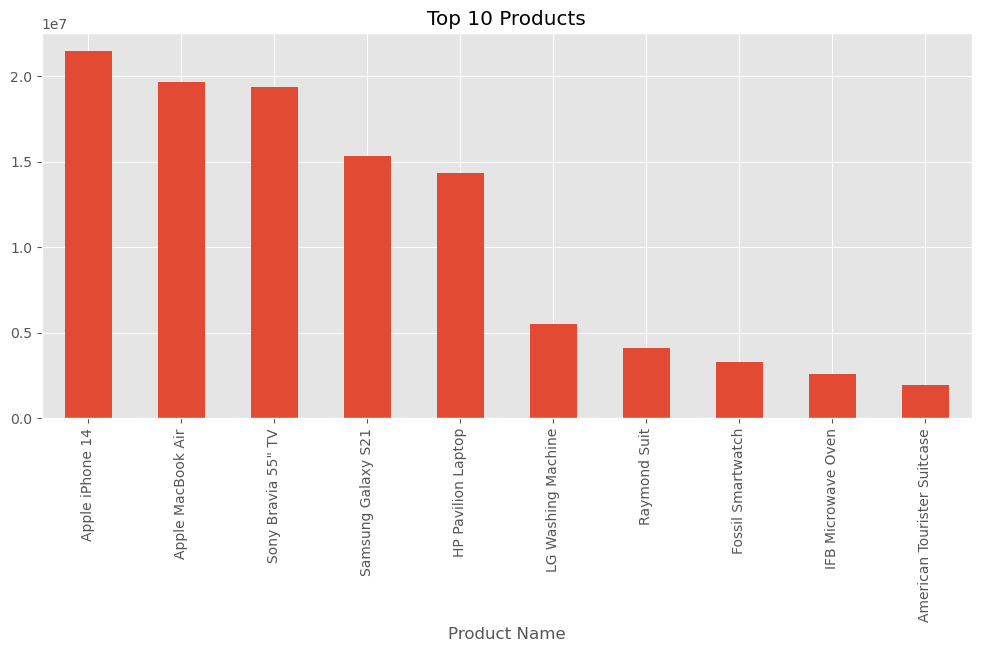

In [71]:
top_products = (
    master.groupby("Product Name")["Net Sales"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products")

plt.show()

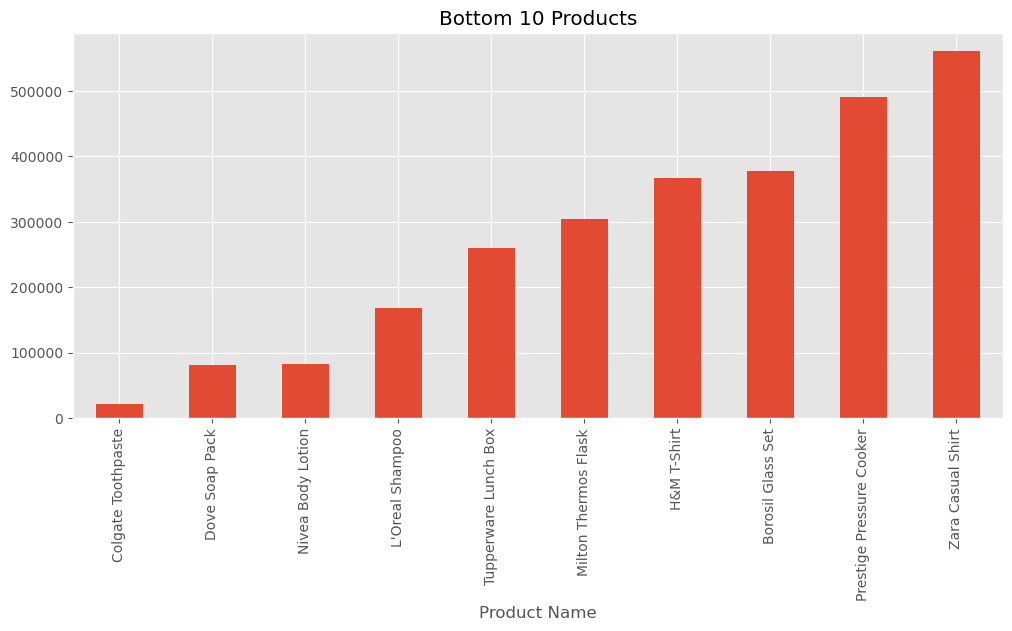

In [72]:
bottom_products = (
    master.groupby("Product Name")["Net Sales"]
    .sum()
    .nsmallest(10)
)

plt.figure(figsize=(12,5))

bottom_products.plot(kind="bar")

plt.title("Bottom 10 Products")

plt.show()

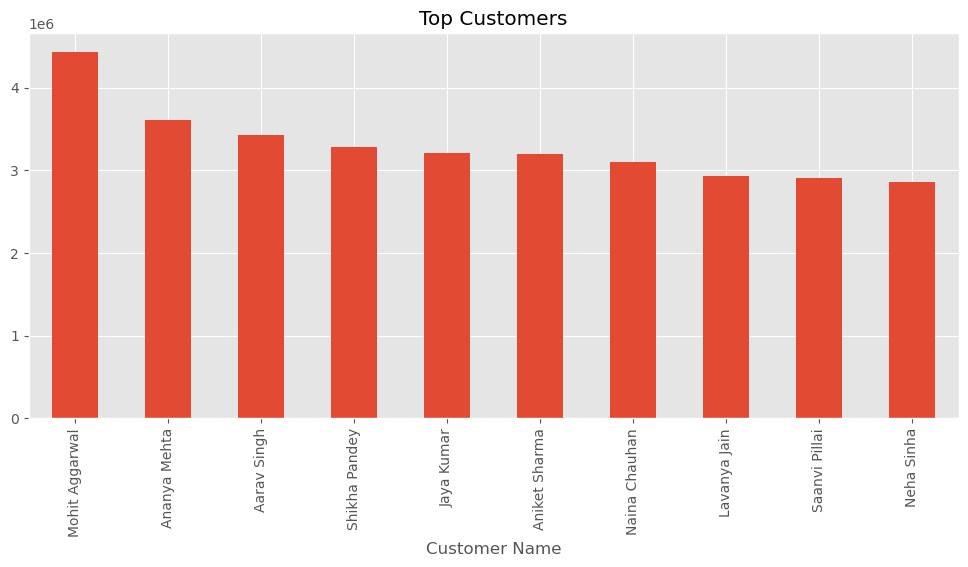

In [73]:
top_customers = (
    master.groupby("Customer Name")["Net Sales"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top Customers")

plt.show()

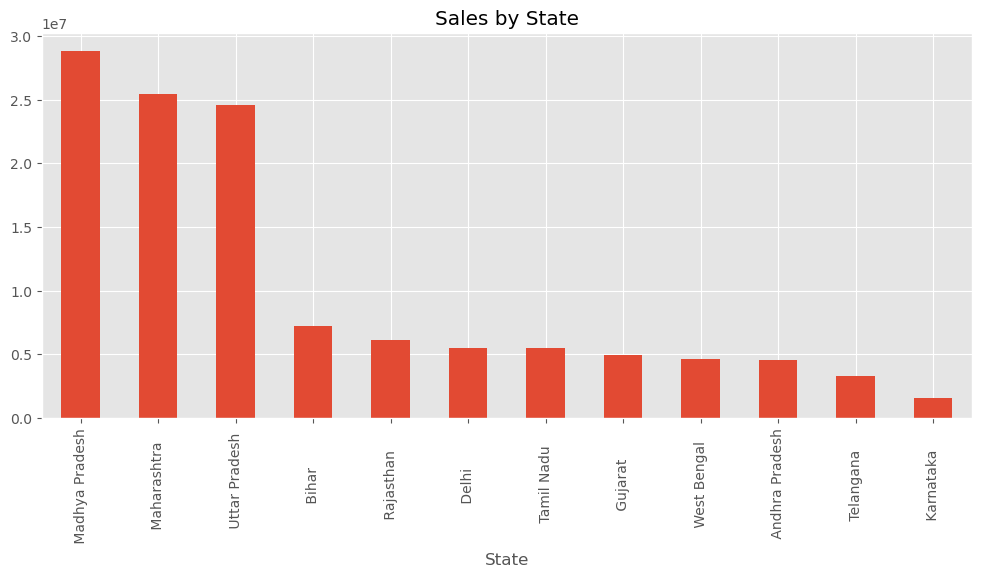

In [74]:
state_sales = (
    master.groupby("State")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

state_sales.plot(kind="bar")

plt.title("Sales by State")

plt.show()

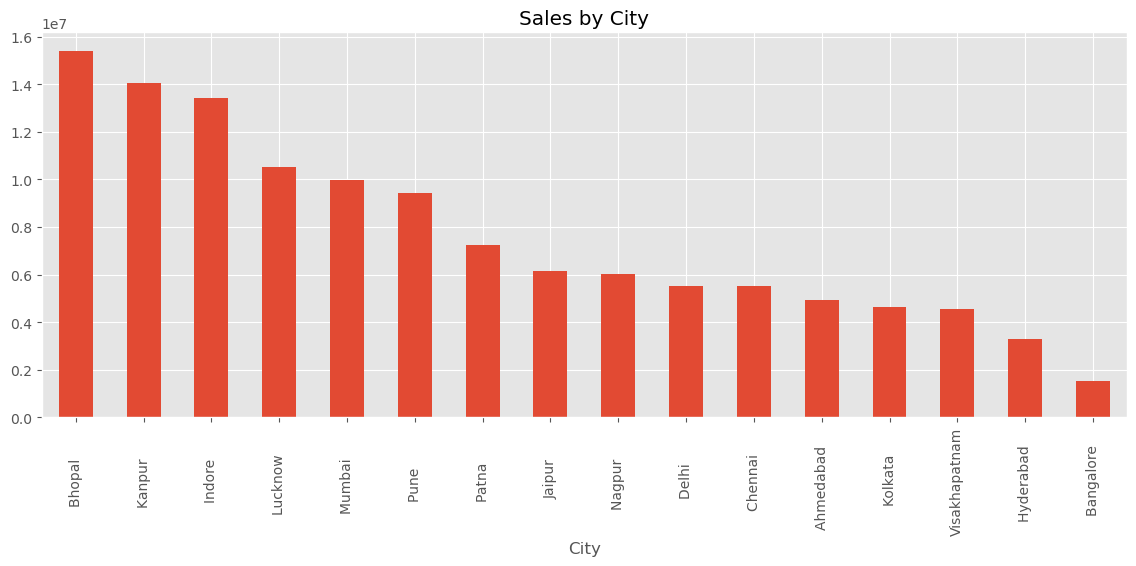

In [75]:
city_sales = (
    master.groupby("City")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,5))

city_sales.plot(kind="bar")

plt.title("Sales by City")

plt.show()

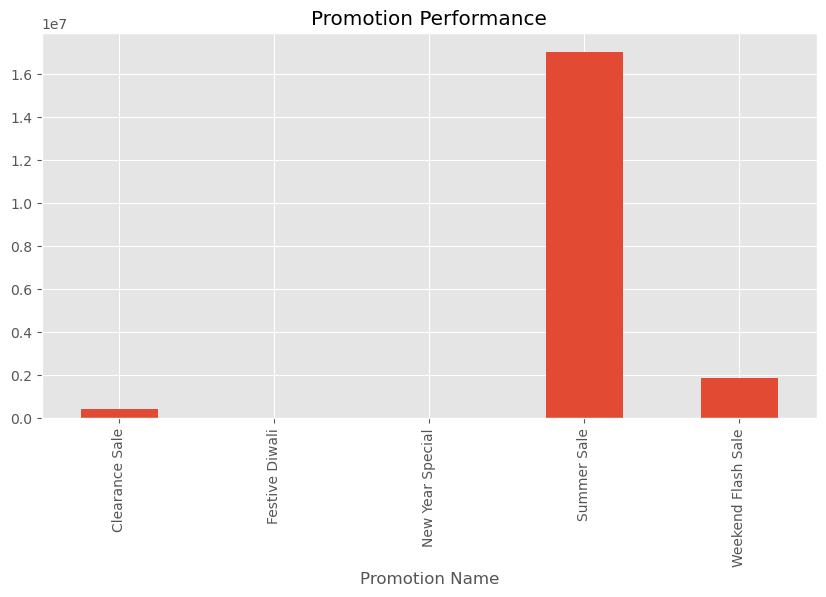

In [76]:
promotion_sales = (
    master.groupby("Promotion Name")["Net Sales"]
    .sum()
)

plt.figure(figsize=(10,5))

promotion_sales.plot(kind="bar")

plt.title("Promotion Performance")

plt.show()

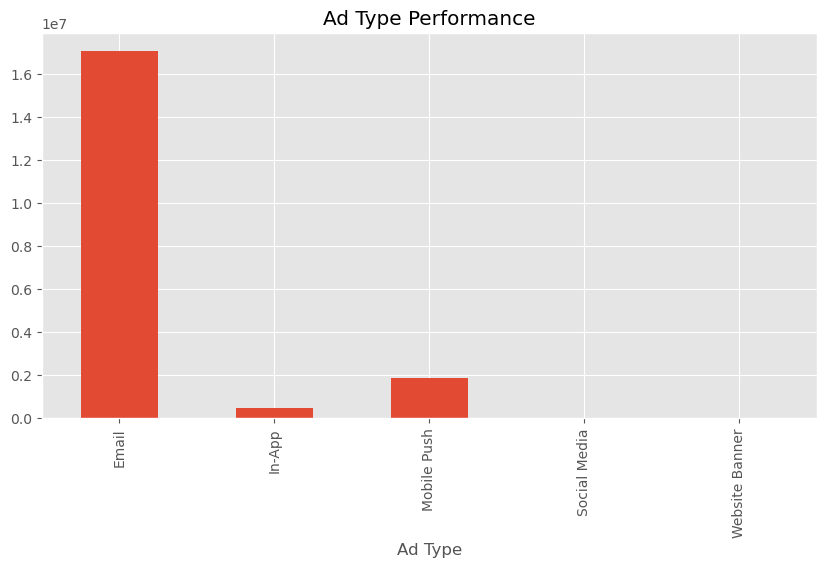

In [77]:
ad_sales = (
    master.groupby("Ad Type")["Net Sales"]
    .sum()
)

plt.figure(figsize=(10,5))

ad_sales.plot(kind="bar")

plt.title("Ad Type Performance")

plt.show()

In [78]:
coupon = (
    master.groupby("Coupon Code")["Net Sales"]
    .sum()
)

coupon.sort_values(ascending=False).head(10)

Coupon Code
SUMMER21       17038699.2
FLASH50         1873543.0
CLEARANCE23      448242.0
NEWYEAR22          6447.0
FESTIVE2022        5396.4
Name: Net Sales, dtype: float64

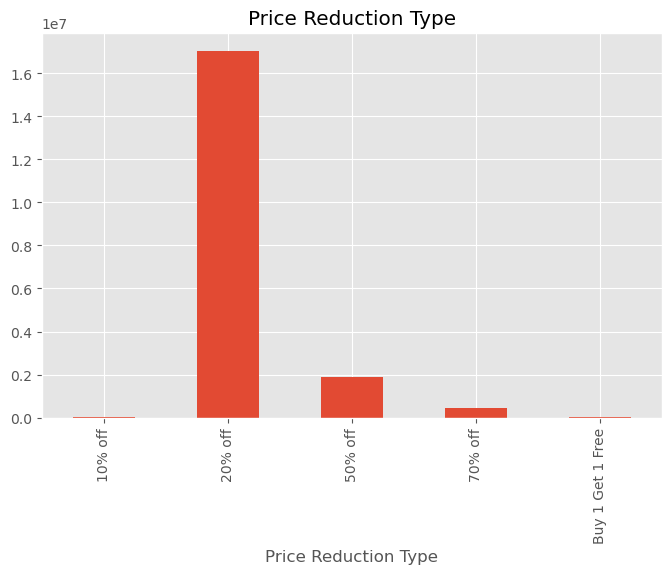

In [79]:
reduction = (
    master.groupby("Price Reduction Type")["Net Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

reduction.plot(kind="bar")

plt.title("Price Reduction Type")

plt.show()

In [80]:
aov = master["Net Sales"].sum() / master["Order ID"].nunique()

print("Average Order Value:", round(aov,2))

Average Order Value: 34845.56


In [81]:
corr = master.select_dtypes(include="number").corr()

corr

,CustomerID,Units Sold,Price Per Unit,Total Sales,Discount Percentage,Discount Value,Net Sales,Profit,Order ID,Year,Quarter,Profit Margin,Pincode,Phone Number,Price (INR)
CustomerID,1.000000,-0.004736,-0.030233,-0.018824,-0.005680,-0.000722,-0.019566,-0.019566,0.016612,-0.004837,0.021645,0.019711,-0.169947,-0.152154,-0.030233
Units Sold,-0.004736,1.000000,0.049232,0.262160,-0.015703,0.092681,0.259033,0.259033,0.037579,-0.011881,-0.004268,0.026963,0.039835,0.016126,0.049232
Price Per Unit,-0.030233,0.049232,1.000000,0.912114,-0.008761,0.321285,0.901425,0.901425,0.023109,-0.014841,0.020963,-0.015208,0.009802,-0.020322,1.000000
Total Sales,-0.018824,0.262160,0.912114,1.000000,-0.004890,0.352180,0.988291,0.988291,0.029343,-0.009406,0.013965,-0.009722,0.017256,-0.026062,0.912114
Discount Percentage,-0.005680,-0.015703,-0.008761,-0.004890,1.000000,0.448282,-0.078195,-0.078195,-0.068478,0.112749,0.041641,0.112057,0.020507,0.001204,-0.008761
Discount Value,-0.000722,0.092681,0.321285,0.352180,0.448282,1.000000,0.205251,0.205251,-0.010202,0.033694,0.007125,0.030846,0.013594,-0.012906,0.321285
Net Sales,-0.019566,0.259033,0.901425,0.988291,-0.078195,0.205251,1.000000,1.000000,0.032347,-0.015329,0.013441,-0.015195,0.015829,-0.025149,0.901425
Profit,-0.019566,0.259033,0.901425,0.988291,-0.078195,0.205251,1.000000,1.000000,0.032347,-0.015329,0.013441,-0.015195,0.015829,-0.025149,0.901425
Order ID,0.016612,0.037579,0.023109,0.029343,-0.068478,-0.010202,0.032347,0.032347,1.000000,0.028311,0.010857,-0.007815,-0.007885,0.005983,0.023109
Year,-0.004837,-0.011881,-0.014841,-0.009406,0.112749,0.033694,-0.015329,-0.015329,0.028311,1.000000,0.020718,0.020216,-0.001724,-0.004353,-0.014841


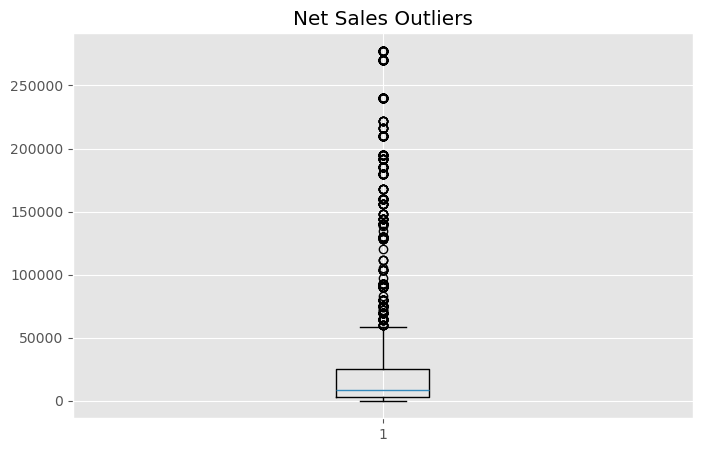

In [82]:
plt.figure(figsize=(8,5))

plt.boxplot(master["Net Sales"])

plt.title("Net Sales Outliers")

plt.show()

In [83]:
print("Total Sales :", master["Total Sales"].sum())
print("Net Sales :", master["Net Sales"].sum())
print("Total Profit :", master["Profit"].sum())
print("Orders :", master["Order ID"].nunique())
print("Customers :", master["Customer Name"].nunique())
print("Products :", master["Product Name"].nunique())
print("Average Order Value :", round(aov,2))
print("Average Profit Margin :", round(master["Profit Margin"].mean(),2))

Total Sales : 129494075
Net Sales : 122307912.6
Total Profit : 12230791.260000002
Orders : 3510
Customers : 50
Products : 30
Average Order Value : 34845.56
Average Profit Margin : 10.0


## Business Insights

**1. Highest sales month:** October is the single strongest month, with ₹1,23,24,091 (₹12.32M) in net sales, just ahead of November (₹1,21,21,323) and September (₹1,14,84,277). At the quarter level, Q4 (Oct–Dec) leads with ₹3.28 crore, though it's driven almost entirely by October and November — December is actually one of the weakest months overall (₹83.9L).

**2. Most profitable product line:** Electronics, by a wide margin. It generated ₹9.01 crore in net sales — about 74% of the ₹12.23 crore total — versus ₹1.15 crore for the next-best line, Home Appliances. Since profit margin is flat at 10% across the dataset, Electronics is also the top line by absolute profit (~₹90.1L).

**3. Top-performing products (by profit):** Apple iPhone 14 (₹21.44L), Apple MacBook Air (₹19.65L), Sony Bravia 55" TV (₹19.36L), Samsung Galaxy S21 (₹15.31L), and HP Pavilion Laptop (₹14.35L). These five products alone account for ~74% of total company profit — and notably, they *are* the Electronics line, explaining why that category dominates insight #2.

**4. Highest-revenue states:** Madhya Pradesh (₹2.88 crore), Maharashtra (₹2.55 crore), and Uttar Pradesh (₹2.46 crore) together contribute ~64% of total net sales. Karnataka is the clear laggard at just ₹15.5L — under 2% of MP's revenue.

**5. Strongest cities:** Bhopal (₹1.54 crore) and Indore (₹1.34 crore) — both in Madhya Pradesh — plus Kanpur (₹1.41 crore) and Lucknow (₹1.05 crore) in Uttar Pradesh, are the standout performers. Mumbai (₹99.9L) is the top metro outside these two states; Bangalore is the weakest city (₹15.5L).

**6. Best-performing promotion:** Summer Sale drove ₹1.70 crore in net sales — over 9x the next-best promotion (Weekend Flash Sale, ₹18.7L). Clearance Sale, New Year Special, and Festive Diwali combined contributed less than ₹4.6L, making them statistically negligible.

**7. Ad type effectiveness:** Email is the dominant channel by far (₹17.04L profit), followed distantly by Mobile Push (₹1.87L). In-App, Website Banner, and Social Media each contributed under ₹45K in profit. Each ad type maps almost 1:1 to a single promotion (Email↔Summer Sale, Mobile Push↔Weekend Flash Sale), so this dataset doesn't show multi-channel promotions — each campaign ran on one channel only.

**8. Discounts vs. profitability:** Profit margin is essentially constant at exactly 10% for every one of the 3,510 orders (std ≈ 0). This means discounting in this dataset reduces the *rupee amount* of sales and profit, but does not erode the margin ratio itself. Correlation analysis backs this up: Discount % has almost no relationship with profit (r = -0.08), while Discount Value correlates weakly with profit (r = 0.21) simply because higher-priced items receive larger absolute discounts. Profitability here is driven by sales volume and price point, not by discount strategy.

**9. Consistently low-sales product lines:** Personal Care (₹3.53L) and Kitchenware (₹9.40L) are far behind every other line — combined they're barely 1% of total net sales, versus Electronics' ~74%.

**10. Overall profit margin:** Across all 3,510 orders, total net sales were ₹12.23 crore (₹1,22,30,791 profit) on a flat 10% margin — meaning margin is fixed by construction in this dataset rather than varying by product, discount, or region. Average order value is ₹34,845.56.

## Recommendations

**Double down on Electronics** — it drives ~74% of revenue and profit (led by iPhone 14, MacBook Air, Sony Bravia TV, Galaxy S21, HP Pavilion). Prioritize inventory, marketing spend, and supplier relationships here over the long tail of Personal Care and Kitchenware.

**Re-evaluate the discount strategy** — since margin is fixed at 10% regardless of discount level, discounts aren't buying extra profitability in this dataset. Investigate whether deeper discounts are actually driving incremental volume, or whether they're simply cutting revenue with no margin benefit.

**Protect and scale inventory for the proven top sellers** (iPhone 14, MacBook Air, Sony Bravia, Galaxy S21, HP Pavilion) rather than spreading stock evenly — they generate a disproportionate share of profit per unit sold.

**Concentrate promotional budget on what works** — Summer Sale (Email) and Weekend Flash Sale (Mobile Push) together account for the overwhelming majority of promotion-driven sales. Clearance Sale, New Year Special, and Festive Diwali are underperforming enough to reconsider, redesign, or retire.

**Expand in high-performing regions, investigate the gap elsewhere** — grow presence in Madhya Pradesh, Maharashtra, and Uttar Pradesh (and their lead cities Bhopal, Indore, Kanpur, Lucknow), while diagnosing why Karnataka/Bangalore underperforms so heavily relative to comparable metros — it may be an under-penetrated market opportunity rather than genuinely weak demand.

## Conclusion

This EDA set out to understand where sales and profit come from across products, regions, promotions, and marketing channels in the e-commerce dataset — and to surface patterns that justify concrete business action rather than just describing the data.

**Key findings:** Electronics is the overwhelming revenue and profit engine (~74% of both), carried by five hero products (iPhone 14, MacBook Air, Sony Bravia TV, Galaxy S21, HP Pavilion). Sales are geographically concentrated in Madhya Pradesh, Maharashtra, and Uttar Pradesh, with Bhopal, Kanpur, and Indore as the standout cities. October is the peak month, and the Summer Sale promotion (run via Email) single-handedly outperforms every other campaign combined. A notable structural finding is that profit margin is fixed at exactly 10% across every transaction, so profitability in this dataset is driven entirely by sales volume and price point rather than by discount depth or product mix.

**Supporting the Power BI dashboard:** the groupings, KPIs, and correlations built here (monthly/quarterly/yearly sales trends, product-line and product-level profitability, state/city revenue splits, promotion and ad-type performance, and the discount–profit relationship) map directly onto the dashboard's core visuals — they define which fields matter, which cuts of the data are meaningful, and which comparisons (e.g., Email vs. other ad types, MP/UP/Maharashtra vs. other states) deserve to be front and center rather than buried in a table. The EDA also caught data-quality context — like the flat 10% margin and the 1:1 ad-type-to-promotion mapping — that a dashboard viewer would otherwise misread as meaningful variation.

**Business decision-making:** together, these findings give leadership a clear, evidence-based basis to prioritize Electronics inventory and marketing spend, reallocate promotional budget away from underperforming campaigns, expand deliberately in proven high-growth regions, and treat discounting as a volume lever rather than a margin lever — turning a descriptive analysis into a set of specific, defensible next steps.